## IMPORTS - Importation des bibliothèques nécessaires

In [2]:
# PIL (Python Imaging Library) pour manipuler et afficher les images
from PIL import Image

# glob pour trouver les fichiers qui correspondent à un motif (ex: *.jpg)
import glob

# chromadb pour créer une base de données vectorielle
import chromadb

# OpenCLIPEmbeddingFunction pour générer les embeddings des images
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

# ImageLoader pour charger et traiter les images dans ChromaDB
from chromadb.utils.data_loaders import ImageLoader

from dotenv.ipython import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import base64
from IPython.display import Markdown

## Chargement des images

In [3]:
# Créer une liste vide pour stocker toutes les images
images_list = []

# Boucler sur tous les fichiers .jpg dans le dossier "vehicules"
for file_name in glob.glob("vehicules/*.jpg"):
    # Ouvrir le fichier image avec PIL
    image = Image.open(file_name)
    # Ajouter l'image à la liste
    images_list.append(image)

## Test affichage d image

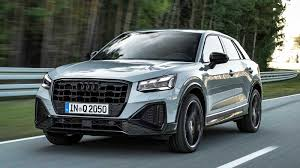

In [4]:
# Afficher la première image de la liste (index 0) pour vérifier que les images sont bien chargées
display(images_list[0])

## Configuration de la BDD vectorielle ChromaDB

In [5]:
# Créer un client ChromaDB persistent - les données seront sauvegardées dans le dossier "images-store-vdb"
chromadb_client = chromadb.PersistentClient(path="images-store-vdb")

# Créer un ImageLoader pour charger les images depuis le disque
image_loader = ImageLoader()

# Créer le modèle d'embedding OpenCLIP qui convertira les images en vecteurs
image_embedding_model = OpenCLIPEmbeddingFunction()

# Créer ou récupérer une collection ChromaDB nommée "images_collection"
# Cette collection stockera les embeddings des images et permettra les recherches par similarité
chroma_vdb = chromadb_client.get_or_create_collection(
    name="images_collection",  # Nom de la collection
    data_loader= image_loader,  # Chargeur d'images,
    embedding_function=image_embedding_model # Fonction pour générer les embeddings
)

c:\Users\Lenovo\Desktop\MesDoc\1-II-BDCC\3-S3\Agentic AI\TPs\TP3-AI-Agent-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from pathlib import Path  # Gérer les chemins de fichiers de façon portable

image_ids = []
image_uris = []
images_folder = Path("vehicules")
for index, image_name in enumerate(sorted(images_folder.iterdir())):
    if image_name.suffix.lower() == ".jpg":  # Vérifier que le fichier est une image .jpg
        image_ids.append(str(index))  # Utiliser l'index comme ID de l'image (0, 1, 2, ...)
        image_uris.append(image_name.as_posix())  # Stocker le chemin avec des / 


In [7]:
print("5 premiers IDs :", image_ids[0:5]) # Afficher les 5 premiers IDs (les indices)
print("5 premiers URIs :", image_uris[0:5]) # Afficher les 5 premiers chemins d'images


5 premiers IDs : ['0', '1', '2', '3', '4']
5 premiers URIs : ['vehicules/1.jpg', 'vehicules/10.jpg', 'vehicules/100.jpg', 'vehicules/11.jpg', 'vehicules/12.jpg']


<h4>OpenCLIP (basé sur CLIP) :</h4>
<ul>
<li>✔️ 1. Prend une image</li>
<li>✔️ 2. Transforme l’image → vecteur numérique (embedding)</li>
</ul>

<p>👉 Ce vecteur représente le contenu sémantique de l’image</p>

<table>
<tr>
<td><img src="overview-a.svg"></td>
<td><img src="overview-b.svg"></td>
</tr>
</table>

In [8]:
""""
Ce que fait ChromaDB ici :
- il lit chaque chemin dans image_uris
- il charge l'image grâce à ImageLoader
- il transforme l'image en vecteur avec OpenCLIPEmbeddingFunction
- il enregistre tout dans la collection images_collection
"""

chroma_vdb.add(
    ids=image_ids,  # Liste des IDs d'images (ex: ["0", "1", "2", ...])
    uris=image_uris  # Liste des chemins d'images (ex: ["vehicules/image1.jpg", "vehicules/image2.jpg", ...])
)

In [9]:
chroma_vdb.count()

107

In [10]:
results = chroma_vdb.query(
    query_texts=["white cars"],  # Requête textuelle pour trouver des images similaires à "une voiture rouge"
    n_results=2,  # Nombre de résultats similaires à retourner
    include=["uris", "distances"]  
)

In [11]:
results

{'ids': [['16', '85']],
 'embeddings': None,
 'documents': None,
 'uris': [['vehicules/141.jpg', 'vehicules/66.jpg']],
 'included': ['uris', 'distances'],
 'data': None,
 'metadatas': None,
 'distances': [[0.728303849697113, 0.7417511940002441]]}

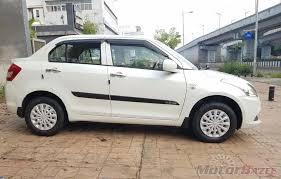

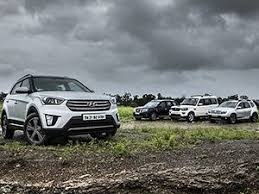

In [12]:
for image_path in results["uris"][0]:  # results["documents"] est une liste de listes d'URIs, on prend la première liste
    image = Image.open(image_path)  # Ouvrir l'image avec PIL
    display(image)  # Afficher l'image

In [24]:
results = chroma_vdb.query(
    query_texts=["red cars"],  # Requête textuelle pour trouver des images similaires à "une voiture rouge"
    n_results=2,  # Nombre de résultats similaires à retourner
    include=["uris", "distances"]  
)

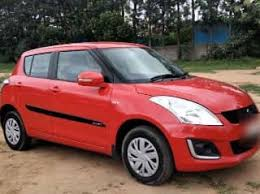

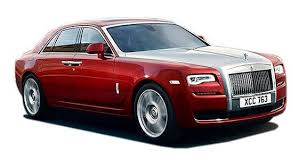

In [25]:
for image_path in results["uris"][0]:  # results["documents"] est une liste de listes d'URIs, on prend la première liste
    image = Image.open(image_path)  # Ouvrir l'image avec PIL
    display(image)  # Afficher l'image  

In [22]:
results = chroma_vdb.query(
    query_texts=["audi  cars"],  # Requête textuelle pour trouver des images similaires à "une voiture rouge"
    n_results=2,  # Nombre de résultats similaires à retourner
    include=["uris", "distances"]  
)

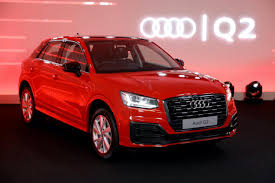

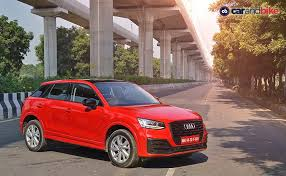

In [23]:
for image_path in results["uris"][0]:  # results["documents"] est une liste de listes d'URIs, on prend la première liste
    image = Image.open(image_path)  # Ouvrir l'image avec PIL
    display(image)  # Afficher l'image  

In [17]:
load_dotenv
llm = ChatOpenAI(model="gpt-4o", temperature=0)
parser=StrOutputParser()
image_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "{system_message}"),
        ("user", [
                {"type":"text","text":"{user_question}"},
                {"type":"image_url","image_url": "data:image/jpeg;base64,{image_data1}"},
                {"type":"image_url","image_url": "data:image/jpeg;base64,{image_data2}"}, 

        ])
    ]
)
vision_chain = image_prompt | llm | parser 

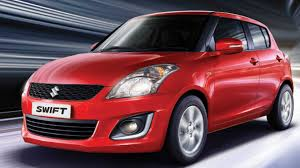

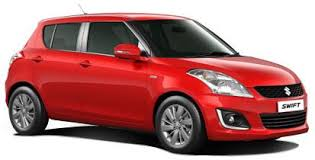

In [18]:
prompt_inputs = {}
system_message ="""""
Answer the question using the given images context 
with references to the parts of the images provided . 
Use Markdown to give your answer.
"""

user_question = "donne moi la description des deux aciennes voitures de couleur rouge"

results = chroma_vdb.query(
    query_texts=[user_question],  # Requête textuelle pour trouver des images similaires à "une voiture rouge"
    n_results=2,  # Nombre de résultats similaires à retourner
    include=["uris", "distances"]  
)
image_paths1 = results["uris"][0][0]  # results["documents"] est une liste de listes d'URIs, on prend la première liste
image_paths2 = results["uris"][0][1]  
display(Image.open(image_paths1))  # Afficher la première image pour vérifier que le chemin est correct
display(Image.open(image_paths2)) 
with open(image_paths1, "rb") as image_file:
    image_data1 = image_file.read()
with open(image_paths2, "rb") as image_file:
    image_data2 = image_file.read()

prompt_inputs["system_message"] = system_message
prompt_inputs["user_question"] = user_question
prompt_inputs["image_data1"] = base64.b64encode(image_data1).decode("utf-8")
prompt_inputs["image_data2"] = base64.b64encode(image_data2).decode("utf-8")


In [19]:
response = vision_chain.invoke(prompt_inputs)

In [20]:
display(Markdown(response))
#print(response)

Les images montrent deux voitures rouges de modèle similaire. Voici une description :

1. **Première voiture** :
   - Couleur : Rouge vif.
   - Modèle : Hatchback compact.
   - Caractéristiques : La voiture a des phares avant inclinés et un design aérodynamique. Le logo de la marque est visible sur la calandre avant.

2. **Deuxième voiture** :
   - Couleur : Rouge vif.
   - Modèle : Hatchback compact.
   - Caractéristiques : Semblable à la première, avec des phares avant inclinés et un design aérodynamique. Le logo de la marque est également visible sur la calandre avant.

Les deux voitures semblent être du même modèle, avec des lignes modernes et sportives.

In [21]:
results

{'ids': [['23', '7']],
 'embeddings': None,
 'documents': None,
 'uris': [['vehicules/151.jpg', 'vehicules/127.jpg']],
 'included': ['uris', 'distances'],
 'data': None,
 'metadatas': None,
 'distances': [[0.7421436309814453, 0.7528077363967896]]}